画更好看的training loss和validation loss图

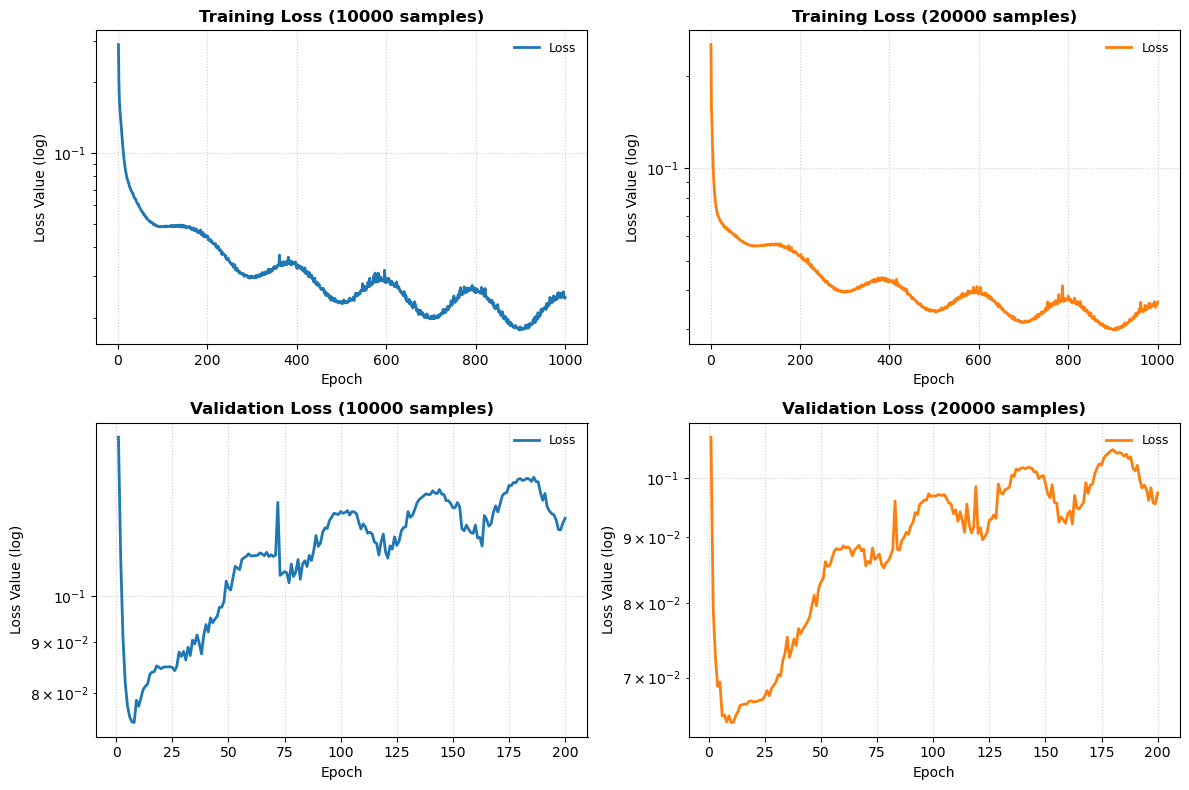

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ========================= 参数配置 =========================
# 四个txt文件的路径（请按以下顺序修改为实际路径）
current_dir = os.getcwd()
train_loss_dir = current_dir + '/train_loss/CosineAnnealingLR_T_max100/lr0.001/'
val_loss_dir = current_dir + '/val_loss/CosineAnnealingLR_T_max100/lr0.001/'
data_type = 'diffusion'
tol_exp = 1000000 # 5 or 1000000
train_loss_file_1 = train_loss_dir + data_type + 'I16N1L4batch256epoch1000d100010000tol' + str(tol_exp) + '_multilevel.txt'   # 第一行左图（训练1）
train_loss_file_2 = train_loss_dir + data_type + 'I16N1L4batch256epoch1000d200020000tol' + str(tol_exp) + '_multilevel.txt'   # 第一行右图（训练2）
val_loss_file_1   = val_loss_dir + data_type + 'I16N1L4batch256epoch1000d100010000tol' + str(tol_exp) + '_multilevel.txt'     # 第二行左图（验证1）
val_loss_file_2   = val_loss_dir + data_type + 'I16N1L4batch256epoch1000d200020000tol' + str(tol_exp) + '_multilevel.txt'     # 第二行右图（验证2）

# 子图标题（可自定义）
titles = [['Training Loss (10000 samples)', 'Training Loss (20000 samples)'],
          ['Validation Loss (10000 samples)', 'Validation Loss (20000 samples)']]

# 是否使用对数Y轴
use_log_scale = True

# 线条颜色（可分别指定四个子图的颜色）
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 按子图顺序
colors = ['#1f77b4', '#ff7f0e','#1f77b4', '#ff7f0e']  # 按子图顺序

# 线条宽度
line_width = 2

# 是否显示网格
show_grid = True

# 图像尺寸（宽，高），单位英寸
figsize = (12, 8)

# # 保存图片的文件名（可修改）
# save_filename = 'loss_curves_2x2.png'   # 也可改为 .pdf
# dpi = 300

# ========================= 辅助函数：读取txt =========================
def read_loss_file(filepath):
    """读取txt，每行一个loss值，返回numpy数组（loss列表）"""
    losses = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    losses.append(float(line))
                except ValueError:
                    print(f"警告：文件 {filepath} 中存在无法解析的行：{line}")
    if len(losses) == 0:
        raise ValueError(f"文件 {filepath} 无有效数据！")
    return np.array(losses)

# ========================= 读取数据 =========================
data = [
    read_loss_file(train_loss_file_1),
    read_loss_file(train_loss_file_2),
    read_loss_file(val_loss_file_1),
    read_loss_file(val_loss_file_2)
]

# ========================= 构建2x2子图 =========================
fig, axes = plt.subplots(2, 2, figsize=figsize)

# 遍历四个子图
for idx, ax in enumerate(axes.flat):
    losses = data[idx]
    epochs = np.arange(1, len(losses) + 1)   # X轴：epoch/iteration
    
    # 绘制曲线
    ax.plot(epochs, losses, color=colors[idx], linewidth=line_width, label='Loss')
    
    # 设置标题
    row = idx // 2   # 0或1
    col = idx % 2    # 0或1
    ax.set_title(titles[row][col], fontsize=12, fontweight='bold')
    
    # 坐标轴标签
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss Value', fontsize=10)
    
    # 对数坐标
    if use_log_scale:
        ax.set_yscale('log')
        ax.set_ylabel('Loss Value (log)', fontsize=10)
    
    # 网格
    if show_grid:
        ax.grid(True, linestyle=':', alpha=0.6)
    
    # 图例
    ax.legend(loc='upper right', frameon=False, fontsize=9)

# 整体调整布局
plt.tight_layout()

# # 保存图片
# plt.savefig(save_filename, dpi=dpi, bbox_inches='tight')
# print(f"图片已保存至：{save_filename}")

# 如需显示（在交互式环境中可取消注释）
plt.show()
plt.close()